## Running new `get_empirical_distributions` on Brendan's data

In [1]:
from ast import literal_eval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/braydenchien/Desktop/Enkavilab/DDM/1ms_trial_data.csv')
df['RT'] = df['RT']*1000
df['fixation'] = df['fixation'].apply(literal_eval)

In [3]:
df.head()

,sub_id,trial,hidden,avgWTP_left,avgWTP_right,choice,RT,fixation
0,329,1,True,1.00,5.0,right,1723.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
1,329,2,True,3.00,5.0,left,2573.0,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,329,3,True,4.25,1.0,left,1775.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
3,329,4,True,3.50,1.0,left,1903.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
4,329,5,True,1.50,1.0,left,1863.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."


In [4]:
dropped_trials_df = pd.read_csv('/Users/braydenchien/Desktop/Enkavilab/DDM/dropped_trials.csv')

# Loop through each row in dropped_trials_df
for _, row in dropped_trials_df.iterrows():
    par = row['parcode']
    trial = row['trial']
    
    # Exclude matching rows from df
    df = df[~((df['sub_id'] == par) & (df['trial'] == trial))]

In [5]:
bin_size = 1 # because the data is in seconds
value_diffs = np.arange(-4, 4.25, 0.25)
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, "blank_fixation": {4}
}
fix_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'

In [6]:
def get_empirical_distributions(
    df: pd.DataFrame,
    bin_size: float,
    value_diffs: list,
    *,
    legend: dict = None,
    fixation_col: str = None,
    v_left_col: str = "avgWTP_left",
    v_right_col: str = "avgWTP_right",
    trial_col: str = None,
    start_col: str = None,
    end_col: str = None,
    location_col: str = None,
    assume_bins: bool = True,
    num_fix_dists: int = 2,
    time_step: float | None = None,
    max_fix_time: float | None = None,
):
    """
    Compute empirical fixation duration, latency, and transition distributions
    from fixation sequences or fixation event tuples, with flexible legend mapping,
    customizable column names, and ordinal fixation buckets.

    Supports either:
        (A) rasterized fixation sequences per trial (via `fixation_col`), or
        (B) start–end–location tuples (via `start_col`, `end_col`, `location_col`, grouped by `trial_col`).

    Estimates:
      • Probability that the first fixation is on the left option
      • Distribution of latencies (time to first fixation)
      • Distribution of transition durations between fixations
      • Fixation duration distributions split by fixation ordinal (1..num_fix_dists,
        with the last bucket pooling Nth+), and binned by signed value difference
        (fixated − unfixated)

    Parameters
    ----------
    df : pandas.DataFrame
        Input data containing either rasterized fixation sequences or fixation events.

    bin_size : float
        Time represented by one element in a fixation sequence, in seconds (or any consistent unit).

    value_diffs : list of float
        The set of possible (or desired) signed value differences to bin by. Each fixation
        duration is assigned to the closest bin in this list.

    legend : dict, optional
        Mapping of raw fixation codes to categories. Example:
            legend = {
                "left": {1},
                "right": {2},
                "transition": {0, 3, 4},
                # "ignore": set()  # optional
            }
        Default: assumes 1 = left, 2 = right, and {0,3,4} = transitions.
        Values may be lists or sets; they’re normalized to sets internally.

    fixation_col : str, optional
        Column containing pre-rasterized fixation sequences (list/array of codes) per trial.
        If provided, `start_col`/`end_col`/`location_col` are ignored.

    v_left_col, v_right_col : str
        Column names for the left/right values per trial (default: "avgWTP_left", "avgWTP_right").

    trial_col : str, optional
        Trial identifier column. Required if reconstructing from events.

    start_col, end_col : str, optional
        Start and end indices (inclusive) for each event row if reconstructing from events.
        If `assume_bins=False`, they are treated as times and converted using `bin_size`.

    location_col : str, optional
        Side for each event row ('left'/'right' strings or codes resolvable via `legend`).

    assume_bins : bool, default True
        If True, start/end are integer bin indices; if False, they are times to be
        converted to indices via `bin_size`.

    num_fix_dists : int, default 2
        Number of ordinal fixation buckets. Buckets are 1..num_fix_dists; the last bucket
        pools all remaining fixations (e.g., with 3 → 1st, 2nd, and 3rd+).

    Returns
    -------
    dict
        {
            "probFixLeftFirst": float,
            "latencies": np.ndarray,        # pre-first-fixation durations
            "transitions": np.ndarray,      # post-first transition durations
            "fixations": {                  # ordinal -> value_diff_bin -> np.ndarray of durations
                1: {vd: np.ndarray, ...},
                2: {vd: np.ndarray, ...},
                ...
                num_fix_dists: {vd: np.ndarray, ...}
            }
        }
    """
    # ---------- Legend normalization ----------
    # Default now distinguishes 0 vs 3 explicitly
    if legend is None:
        legend = {"left": {1}, "right": {2}, "transition": {0}, "blank_fixation": {3}}
    Lset = set(legend.get("left", set()))
    Rset = set(legend.get("right", set()))
    Tset = set(legend.get("transition", {0}))   # codes that behave like 0 (transitions)
    Bset = set(legend.get("blank_fixation", {3}))   # codes that behave like 3 (do NOT count as transitions after first fix)
    ignore_set = set(legend.get("ignore", set()))

    def classify(code):
        if code in ignore_set:
            return None
        if code in Lset:
            return "L"
        if code in Rset:
            return "R"
        if code in Tset:
            return "T"
        if code in Bset:
            return "B"
        return "T"        # default any other encodings as a transition

    def closest_bin(x, bins):
        return min(bins, key=lambda b: abs(x - b))

    def rasterize_from_events(events_df):
        if events_df.empty:
            return np.array([], dtype=object)
        if assume_bins:
            start_idx = events_df[start_col].to_numpy(dtype=int)
            end_idx   = events_df[end_col].to_numpy(dtype=int)
        else:
            start_idx = np.floor(events_df[start_col].to_numpy() / bin_size).astype(int)
            end_idx   = np.floor(events_df[end_col].to_numpy() / bin_size).astype(int)
        L = int(np.max(end_idx)) + 1
        seq = np.empty(L, dtype=object)
        seq[:] = None
        locs = events_df[location_col].to_numpy()
        for s, e, loc in zip(start_idx, end_idx, locs):
            if isinstance(loc, str):
                key = loc.strip().lower()
                code = "left" if key == "left" else ("right" if key == "right" else loc)
            else:
                code = loc
            seq[s:e+1] = code
        mask_none = (seq == None)  # noqa: E711
        if mask_none.any():
            seq[mask_none] = 0
        return seq

    # ---------- Output containers ----------
    valueDiffs = list(value_diffs)
    fixations_dict = {k: {v: [] for v in valueDiffs} for k in range(1, num_fix_dists + 1)}
    latencies_list, transitions_list = [], []
    count_left_first = 0
    count_total_first = 0

    # ---------- Iterate trials ----------
    if fixation_col is not None:
        trial_iter = df.itertuples(index=False)
        get_seq = lambda row: getattr(row, fixation_col)
        get_vL = lambda row: getattr(row, v_left_col)
        get_vR = lambda row: getattr(row, v_right_col)
    else:
        if not all([trial_col, start_col, end_col, location_col]):
            raise ValueError("To reconstruct from events, provide trial_col, start_col, end_col, and location_col.")
        grouped = df.groupby(trial_col, sort=False)
        def event_trial_iter():
            for trial_id, g in grouped:
                if v_left_col not in g or v_right_col not in g:
                    raise ValueError(f"Missing {v_left_col}/{v_right_col} for trial {trial_id}.")
                vL = g.iloc[0][v_left_col]
                vR = g.iloc[0][v_right_col]
                seq = rasterize_from_events(g)
                yield trial_id, seq, vL, vR
        trial_iter = event_trial_iter()
        get_seq = lambda item: item[1]
        get_vL  = lambda item: item[2]
        get_vR  = lambda item: item[3]

    for row in trial_iter:
        raw_seq = np.asarray(get_seq(row), dtype=object)
        if raw_seq.size == 0:
            continue

        # Classify each bin
        cls = np.array([classify(c) for c in raw_seq], dtype=object)
        keep = cls != None  # noqa: E711
        if not np.any(keep):
            continue
        cls = cls[keep]

        v_left  = float(get_vL(row))
        v_right = float(get_vR(row))
        sv_lookup = {"L": v_left - v_right, "R": v_right - v_left}

        lr_idx = np.flatnonzero((cls == "L") | (cls == "R"))
        if lr_idx.size <= 1:
            continue

        # Exclude the final censored L/R run from the tail
        exclude = np.zeros(cls.size, dtype=bool)
        last_i = lr_idx[-1]
        last_label = cls[last_i]
        j = last_i
        while j >= 0 and cls[j] == last_label:
            exclude[j] = True
            j -= 1
        exclude[last_i + 1 :] = True

        # Iterate runs (NOTE: with N0 vs N3, these do NOT merge)
        N = cls.size
        i = 0
        first_fix_reached = False
        latency_time = 0.0
        fix_number = 1

        while i < N:
            if exclude[i]:
                i += 1
                continue

            lab = cls[i]

            # grow contiguous run of same 'lab' (skipping excluded positions)
            start = i
            i += 1
            while i < N and (exclude[i] or cls[i] == lab):
                i += 1

            # run length in included bins
            run_len = np.count_nonzero(~exclude[start:i])
            if run_len == 0:
                continue
            dur = run_len * bin_size

            if lab in ("L", "R"):
                if not first_fix_reached:
                    first_fix_reached = True
                    count_total_first += 1
                    if lab == "L":
                        count_left_first += 1
                    latencies_list.append(latency_time)

                b = closest_bin(sv_lookup[lab], valueDiffs)
                bucket = min(fix_number, num_fix_dists)
                fixations_dict[bucket][b].append(dur)
                fix_number += 1

            elif lab in ("T", "B"):
                # BEFORE first fixation: both T and B contribute to latency
                if not first_fix_reached:
                    latency_time += dur
                else:
                    # AFTER first fixation: treat each T or B run as its own transition
                    ok_lo = (time_step is None) or (dur >= time_step)
                    ok_hi = (max_fix_time is None) or (dur <= max_fix_time)
                    if ok_lo and ok_hi:
                        transitions_list.append(dur)

        prob_fix_left_first = (count_left_first / count_total_first) if count_total_first > 0 else np.nan

    return {
        "probFixLeftFirst": prob_fix_left_first,
        "latencies": np.array(latencies_list, dtype=float),
        "transitions": np.array(transitions_list, dtype=float),
        "fixations": {
            k: {kk: np.array(vv, dtype=float) for kk, vv in v.items()}
            for k, v in fixations_dict.items()
        }
    }

In [7]:
empirical_distributions = get_empirical_distributions(
    df, 
    bin_size, 
    value_diffs, 
    legend=legend, 
    fixation_col=fix_col, 
    v_left_col=left_value_col, 
    v_right_col=right_value_col,
    num_fix_dists=3,
    time_step=10,
    max_fix_time=3000
)

In [8]:
def _as_1d_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    return np.asarray(x, dtype=float).ravel()

def _fix_lengths_per_key(fix_map):
    """
    fix_map: dict where keys are floats in [-4.0, 4.0] step 0.25
             and values are array-like (whose lengths we count).
    Returns (keys_sorted_float, lengths_per_key_as_float).
    """
    if not isinstance(fix_map, dict) or not fix_map:
        return np.array([], dtype=float), np.array([], dtype=float)
    # Sort keys numerically to keep the x-axis ordered
    keys = sorted(fix_map.keys(), key=float)
    lengths = [len(_as_1d_float_array(fix_map[k])) for k in keys]
    return np.array(keys, dtype=float), np.array(lengths, dtype=float)

def _set_sparse_xticks(ax, xs, every=4, rotation=0):
    """Show only every Nth tick to reduce clutter."""
    if xs.size == 0:
        return
    idx = np.arange(xs.size)
    show = (idx % every) == 0
    ax.set_xticks(xs[show])
    ax.set_xticklabels([f"{v:g}" for v in xs[show]], rotation=rotation)

def plot_empirical_distributions(ed, *, tick_every=4):
    """
    ed: dict with keys:
        - 'latencies': np.ndarray of floats
        - 'transitions': np.ndarray of floats
        - 'fixations': dict {1: dict{float_key: array}, 2: dict{float_key: array}}

    Creates a 2x2 figure:
      (1,1) histogram of ed['latencies']
      (1,2) histogram of ed['transitions']
      (2,1) bar chart: keys of fixations[1] on x, lengths of arrays as heights
      (2,2) bar chart: keys of fixations[2] on x, lengths of arrays as heights
    """
    latencies = _as_1d_float_array(ed.get('latencies', np.array([])))
    transitions = _as_1d_float_array(ed.get('transitions', np.array([])))

    fix = ed.get('fixations', {}) if isinstance(ed, dict) else {}
    fix1 = fix.get(1, {})
    fix2 = fix.get(2, {})

    keys1, lens1 = _fix_lengths_per_key(fix1)
    keys2, lens2 = _fix_lengths_per_key(fix2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax11, ax12, ax21, ax22 = axes.ravel()

    # Top row: true histograms (continuous/binning)
    ax11.hist(latencies, bins=40)
    ax11.set_title("Latencies")
    ax11.set_xlabel("Latency")
    ax11.set_ylabel("Count")

    ax12.hist(transitions, bins=40)
    ax12.set_title("Transitions")
    ax12.set_xlabel("Transition value")
    ax12.set_ylabel("Count")

    # Bottom row: fixed-bin “histograms” → bar charts at the exact key values
    if keys1.size:
        # width smaller than the 0.25 spacing to leave a small gap
        ax21.bar(keys1, lens1, width=0.20, align='center')
        ax21.set_xlim(keys1.min() - 0.2, keys1.max() + 0.2)
        _set_sparse_xticks(ax21, keys1, every=tick_every, rotation=90)
    ax21.set_title("First Fixations: count per key")
    ax21.set_xlabel("Signed Value Difference")
    ax21.set_ylabel("Count (length of array)")

    if keys2.size:
        ax22.bar(keys2, lens2, width=0.20, align='center')
        ax22.set_xlim(keys2.min() - 0.2, keys2.max() + 0.2)
        _set_sparse_xticks(ax22, keys2, every=tick_every, rotation=90)
    ax22.set_title("Second Fixations: count per key")
    ax22.set_xlabel("Signed Value Difference")
    ax22.set_ylabel("Count (length of array)")

    fig.suptitle("Empirical Distributions", y=0.98)
    fig.tight_layout()
    return fig, axes

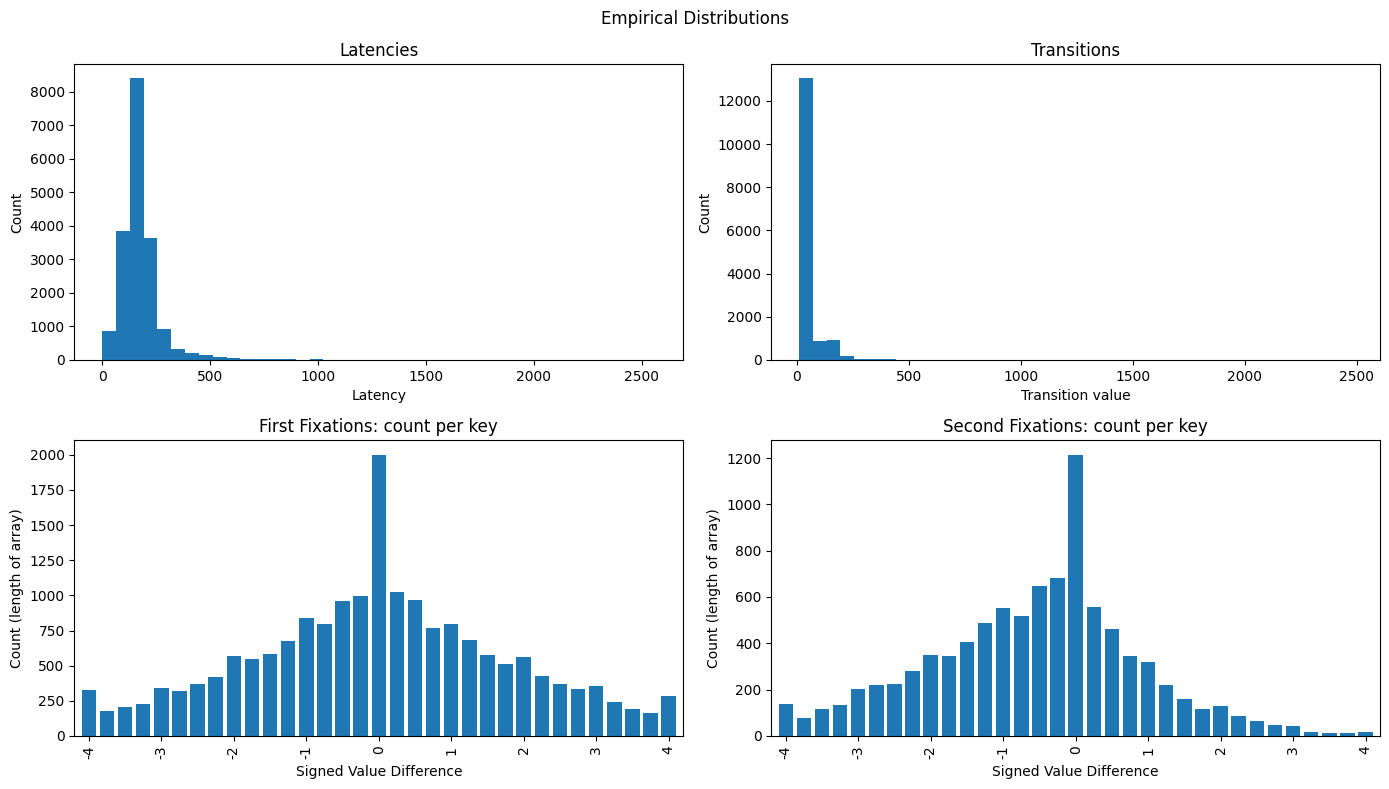

In [9]:
fig, axes = plot_empirical_distributions(empirical_distributions, tick_every=4)
plt.show()

In [10]:
def rasterize_fixations(seq: np.ndarray) -> pd.DataFrame:
    """
    Single-trial: sequence (1D array of ints) -> long DataFrame of fixations.
    Keeps only columns ['fix_start', 'fix_end', 'fix_location'].

    Conventions
    -----------
    - fix_start and fix_end are BOTH inclusive.
    - fix_location is the code value at that fixation.
    """
    seq = np.asarray(seq)
    if seq.ndim != 1:
        raise ValueError("Input must be a 1D numpy array representing one trial.")
    if seq.size == 0:
        return pd.DataFrame(columns=["fix_start", "fix_end", "fix_location"])

    # Run-length encode
    changes = np.flatnonzero(np.diff(seq, prepend=seq[0] - 1))
    starts = changes
    ends_excl = np.r_[changes[1:], seq.size]
    labels = seq[starts]

    rows = []
    for s, e_excl, lab in zip(starts, ends_excl, labels):
        if lab in (0,4):  # skip transitions
            continue
        e_incl = e_excl - 1
        rows.append({
            "fix_start": int(s),
            "fix_end": int(e_incl),
            "fix_location": int(lab)
        })

    return pd.DataFrame(rows)

def rasterize_data(
    df: pd.DataFrame,
    *,
    parcode_col: str = "parcode",
    trial_col: str = "trial",
    seq_col: str = "sequence",
    keep_cols: "str | list[str]" = "all",   # "all" or a list of column names to keep
    drop_seq_in_output: bool = True,        # don't include the sequence column in the output
) -> pd.DataFrame:
    """
    Expand per-row fixation sequences into long-format fixations and
    preserve original row metadata.

    Returns a DataFrame with:
      [<kept metadata cols>, 'fix_start', 'fix_end', 'fix_location']

    Parameters
    ----------
    df : DataFrame with at least [parcode_col, trial_col, seq_col]
    parcode_col, trial_col, seq_col : str
        Column names for participant, trial, and 1D fixation sequence.
    keep_cols : "all" | list[str]
        - "all": keep every column from `df` except `seq_col` (default).
        - list: keep only these columns (they will be added to the output).
    drop_seq_in_output : bool
        If True, the sequence column is not included in the output.
    """
    req = [parcode_col, trial_col, seq_col]
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Decide which metadata columns to keep
    if keep_cols == "all":
        meta_cols = [c for c in df.columns if c != seq_col]
        if drop_seq_in_output is False:  # rare: user wants sequence copied too
            meta_cols = list(df.columns)
    else:
        meta_cols = list(dict.fromkeys(keep_cols))  # dedupe, preserve order
        # Always ensure IDs exist in output
        for c in (parcode_col, trial_col):
            if c not in meta_cols:
                meta_cols.append(c)

    out_frames = []

    for _, row in df.iterrows():
        seq = np.asarray(row[seq_col])
        ras = rasterize_fixations(seq)  # uses your inclusive convention, skips 0s
        if ras.empty:
            continue

        # Attach metadata from the source row to each rasterized segment
        for c in meta_cols:
            ras[c] = row[c]

        # Order columns: metadata first, then fixation columns
        cols_order = [*meta_cols, "fix_start", "fix_end", "fix_location"]
        ras = ras[cols_order]
        out_frames.append(ras)

    if not out_frames:
        return pd.DataFrame(columns=[*meta_cols, "fix_start", "fix_end", "fix_location"])

    return pd.concat(out_frames, ignore_index=True)

df_rasterized = rasterize_data(df, parcode_col='sub_id',trial_col='trial',seq_col='fixation')

In [11]:
df_rasterized.head()

,sub_id,trial,hidden,avgWTP_left,avgWTP_right,choice,RT,fix_start,fix_end,fix_location
0,329,1,True,1.0,5.0,right,1723.0,210,775,1
1,329,1,True,1.0,5.0,right,1723.0,794,1722,2
2,329,2,True,3.0,5.0,left,2573.0,396,1150,1
3,329,2,True,3.0,5.0,left,2573.0,1169,2072,2
4,329,2,True,3.0,5.0,left,2573.0,2089,2572,1


In [12]:
# Keep current order to restore later
df_rasterized["_row_order"] = np.arange(len(df_rasterized))

# Sort within each (parcode, trial) so "first" means earliest fix_start (then fix_end as tiebreaker)
df_rasterized = df_rasterized.sort_values(
    ["sub_id", "trial", "fix_start", "fix_end"],
    kind="mergesort"  # stable sort, keeps ties predictable
)

# Forward order index per group: 1,2,3,...
df_rasterized["fix_num"] = (
    df_rasterized
    .groupby(["sub_id", "trial"])
    .cumcount() + 1
)

# Reverse order: size - rank + 1
group_sizes = df_rasterized.groupby(["sub_id", "trial"])["fix_num"].transform("max")
df_rasterized["fix_num_rev"] = group_sizes - df_rasterized["fix_num"] + 1

# Restore original row order
df_rasterized = df_rasterized.sort_values("_row_order").drop(columns="_row_order")

df_rasterized.head()

,sub_id,trial,hidden,avgWTP_left,avgWTP_right,choice,RT,fix_start,fix_end,fix_location,fix_num,fix_num_rev
0,329,1,True,1.0,5.0,right,1723.0,210,775,1,1,2
1,329,1,True,1.0,5.0,right,1723.0,794,1722,2,2,1
2,329,2,True,3.0,5.0,left,2573.0,396,1150,1,1,3
3,329,2,True,3.0,5.0,left,2573.0,1169,2072,2,2,2
4,329,2,True,3.0,5.0,left,2573.0,2089,2572,1,3,1


In [13]:
df_rasterized['fix_dur'] = df_rasterized['fix_end']-df_rasterized['fix_start']
df_rasterized['choice'] = df_rasterized['choice'].map({'left': 0, 'right': 1})

df_hidden = df_rasterized.loc[df_rasterized['hidden']==True]
df_visible = df_rasterized.loc[df_rasterized['hidden']==False]

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem

def plot_fixation_properties(df: pd.DataFrame):
    """Visualize fixation properties directly from a DataFrame."""
    fig1, axs = plt.subplots(1, 5, figsize=(25, 4))

    # First fixation toward higher value
    first_fix_df = df[df['fix_num'] == 1].copy()
    first_fix_df['abs_diff'] = np.abs(first_fix_df['avgWTP_left'] - first_fix_df['avgWTP_right'])
    first_fix_df['larger_side'] = np.where(first_fix_df['avgWTP_left'] > first_fix_df['avgWTP_right'], 1, 2)
    first_fix_df['toward_larger'] = first_fix_df['fix_location'] == first_fix_df['larger_side']
    first_fix_df['diff_bin'] = pd.cut(first_fix_df['abs_diff'], bins=[0.5, 1.5, 2.5, 3.5, 4.5], labels=[1, 2, 3, 4])
    summary = first_fix_df.groupby('diff_bin')['toward_larger'].agg(['mean', sem]).reset_index()
    summary.columns = ['diff_bin', 'mean_toward_larger', 'sem_toward_larger']

    axs[0].axhline(0.5, color='grey', linestyle='--')
    axs[0].errorbar(summary['diff_bin'].astype(int), summary['mean_toward_larger'],
                    yerr=summary['sem_toward_larger'], fmt='o-', capsize=5)
    axs[0].set_xlabel('Best - Worst')
    axs[0].set_ylabel('P(First Fixation to Best)')
    axs[0].set_ylim(0, 1)
    axs[0].set_xlim(0.75, 4.25)
    axs[0].grid(True)

    # Fixation duration by type
    middle_fix_df = df[(df['fix_num'] != 1) & (df['fix_num_rev'] != 1)].copy()
    last_fix_df = df[df['fix_num_rev'] == 1].copy()
    means = [first_fix_df['fix_dur'].mean(), middle_fix_df['fix_dur'].mean(), last_fix_df['fix_dur'].mean()]
    errors = [sem(first_fix_df['fix_dur']), sem(middle_fix_df['fix_dur']), sem(last_fix_df['fix_dur'])]
    axs[1].bar(['First', 'Middle', 'Last'], means, yerr=errors, capsize=5)
    axs[1].set_ylabel('Fixation Duration (ms)')
    axs[1].grid(axis='y')

    # Middle fixation duration by difficulty
    middle_fix_df['abs_diff'] = np.abs(middle_fix_df['avgWTP_left'] - middle_fix_df['avgWTP_right'])
    middle_fix_df['diff_bin'] = pd.cut(middle_fix_df['abs_diff'],
                                       bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5],
                                       labels=[0, 1, 2, 3, 4])
    summary = middle_fix_df.groupby('diff_bin')['fix_dur'].agg(['mean', sem]).reset_index()
    summary.columns = ['difficulty', 'mean_fix_dur', 'sem_fix_dur']
    axs[2].errorbar(summary['difficulty'], summary['mean_fix_dur'],
                    yerr=summary['sem_fix_dur'], fmt='o-', capsize=5)
    axs[2].set_xlabel('Best - Worst')
    axs[2].set_ylabel('Middle Fixation Duration (ms)')
    axs[2].set_xticks([0, 1, 2, 3, 4])
    axs[2].set_xlim(-0.25, 4.25)
    axs[2].grid(True)

    # First fixation duration by difficulty
    first_fix_df['diff_bin'] = pd.cut(first_fix_df['abs_diff'],
                                      bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5],
                                      labels=[0, 1, 2, 3, 4])
    summary = first_fix_df.groupby('diff_bin')['fix_dur'].agg(['mean', sem]).reset_index()
    summary.columns = ['difficulty', 'mean_fix_dur', 'sem_fix_dur']
    axs[3].errorbar(summary['difficulty'], summary['mean_fix_dur'],
                    yerr=summary['sem_fix_dur'], fmt='o-', capsize=5)
    axs[3].set_xlabel('Best - Worst')
    axs[3].set_ylabel('First Fixation Duration (ms)')
    axs[3].set_xticks([0, 1, 2, 3, 4])
    axs[3].grid(True)

    # Net fixation duration by signed difficulty
    df['signed_diff'] = df['avgWTP_left'] - df['avgWTP_right']
    df['signed_fix_dur'] = np.where(df['fix_location'] == 1, df['fix_dur'], -df['fix_dur'])
    trial_durations = df.groupby(['sub_id', 'trial']).agg({'signed_fix_dur': 'sum', 'signed_diff': 'first'}).reset_index()
    trial_durations['diff_bin'] = pd.cut(trial_durations['signed_diff'],
                                         bins=np.arange(-4.5, 5, 1),
                                         labels=np.arange(-4, 5))
    summary = trial_durations.groupby('diff_bin')['signed_fix_dur'].agg(['mean', sem]).reset_index()
    summary.columns = ['diff_bin', 'mean_net_dur', 'sem_net_dur']
    summary['bin_x'] = summary['diff_bin'].astype(int)

    axs[4].errorbar(summary['bin_x'], summary['mean_net_dur'],
                    yerr=summary['sem_net_dur'], fmt='o-', capsize=5)
    axs[4].axhline(0, color='gray', linestyle='--')
    axs[4].set_xlabel('Left - Right')
    axs[4].set_ylabel('Net Fixation Duration (ms)')
    axs[4].set_xticks(np.arange(-4, 5))
    axs[4].grid(True)

    fig1.tight_layout()
    plt.show()

def plot_basic_psychometrics(df: pd.DataFrame):
    """Visualize basic psychometrics directly from a DataFrame."""
    fig2, axs = plt.subplots(1, 3, figsize=(20, 4))

    # Choice by signed difficulty
    first_fix_df = df[df['fix_num'] == 1].copy()
    first_fix_df['signed_diff'] = first_fix_df['avgWTP_left'] - first_fix_df['avgWTP_right']
    first_fix_df['diff_bin'] = pd.cut(first_fix_df['signed_diff'], bins=np.arange(-4, 4.25, 0.25))
    prob_left_by_bin = first_fix_df.groupby('diff_bin')['choice'].apply(lambda x: (x == 0).mean())
    bin_centers = first_fix_df.groupby('diff_bin')['signed_diff'].mean()

    axs[0].plot(bin_centers, prob_left_by_bin, marker='o', linestyle='-')
    axs[0].axhline(0.5, color='gray', linestyle='--')
    axs[0].set_xlabel("Left - Right")
    axs[0].set_ylabel("P(Choose Left)")
    axs[0].grid(True)

    # Response time by difficulty
    first_fix_df['abs_diff'] = np.abs(first_fix_df['avgWTP_left'] - first_fix_df['avgWTP_right'])
    first_fix_df['diff_bin'] = pd.cut(first_fix_df['abs_diff'],
                                      bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5],
                                      labels=[0, 1, 2, 3, 4])
    summary = first_fix_df.groupby('diff_bin')['RT'].agg(['mean', sem]).reset_index()
    summary.columns = ['diff_bin', 'mean_RT', 'sem_RT']
    summary['mean_RT'] *= 1000
    summary['sem_RT'] *= 1000

    axs[1].errorbar(summary['diff_bin'].astype(int), summary['mean_RT'],
                    yerr=summary['sem_RT'], fmt='o-', capsize=5)
    axs[1].set_xlabel("Best - Worst")
    axs[1].set_ylabel("Response Time (ms)")
    axs[1].set_xticks([0, 1, 2, 3, 4])
    axs[1].grid(True)

    # Number of fixations by difficulty
    summary = first_fix_df.groupby('diff_bin')['fix_num_rev'].agg(['mean', sem]).reset_index()
    summary.columns = ['diff_bin', 'mean_n_fixations', 'sem_n_fixations']
    summary['bin_x'] = summary['diff_bin'].astype(float)

    axs[2].errorbar(summary['bin_x'], summary['mean_n_fixations'],
                    yerr=summary['sem_n_fixations'], fmt='o-', capsize=5, color='tab:red')
    axs[2].set_xlabel("Best - Worst")
    axs[2].set_ylabel("Number of Fixations")
    axs[2].grid(True)

    fig2.tight_layout()
    plt.show()

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = first_fix_df.groupby('diff_bin')['toward_larger'].agg(['mean', sem]).reset_index()
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = middle_fix_df.groupby('diff_bin')['fix_dur'].agg(['mean', sem]).reset_index()
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a futur

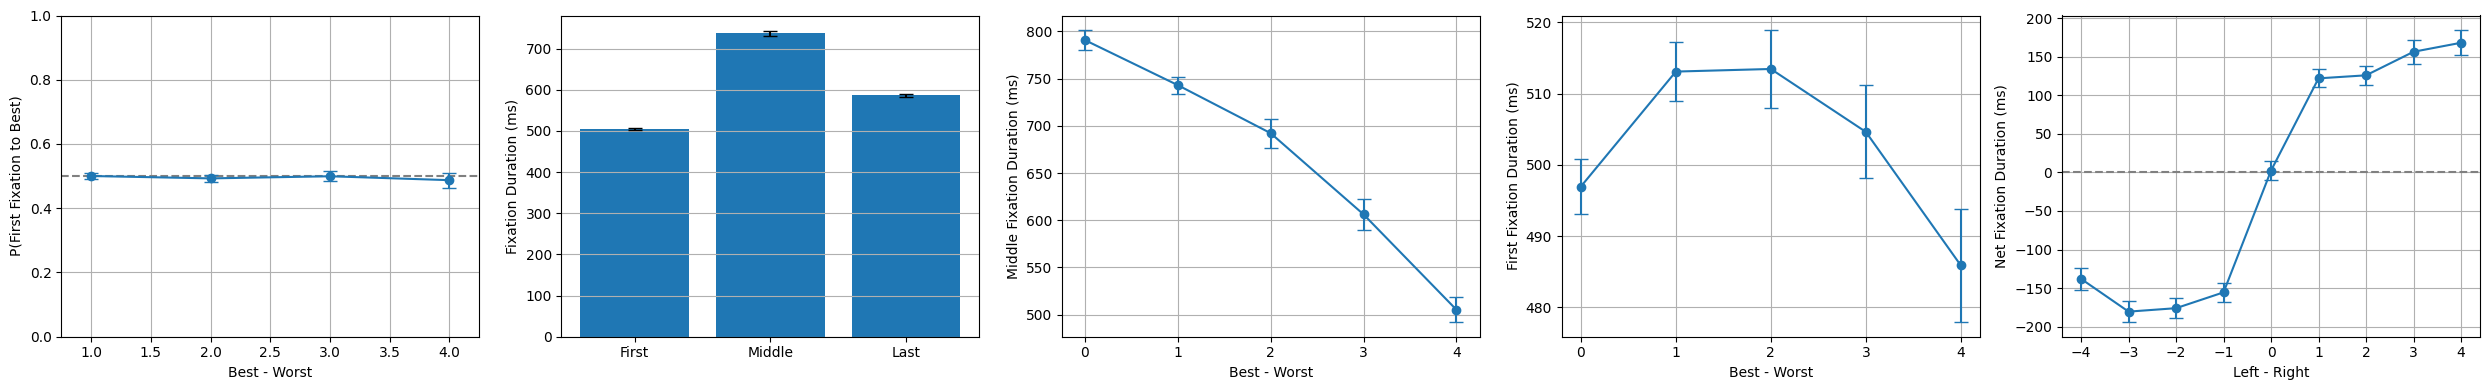

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_left_by_bin = first_fix_df.groupby('diff_bin')['choice'].apply(lambda x: (x == 0).mean())
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = first_fix_df.groupby('diff_bin')['signed_diff'].mean()
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:109: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pan

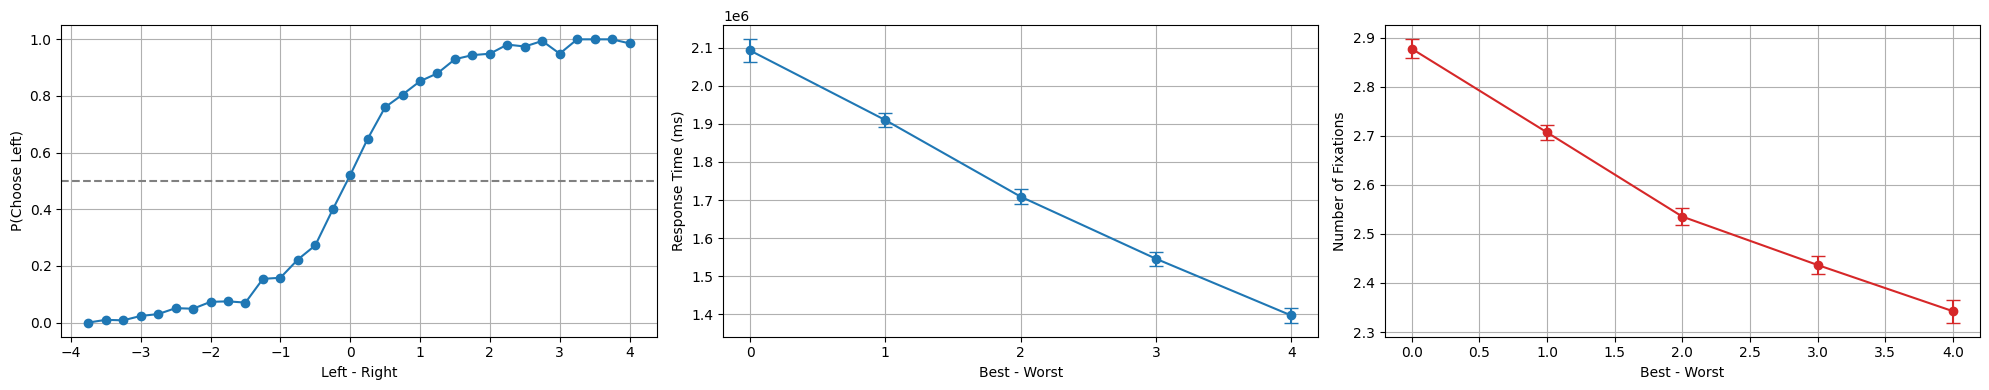

In [15]:
plot_fixation_properties(df_hidden)
plot_basic_psychometrics(df_hidden)

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = first_fix_df.groupby('diff_bin')['toward_larger'].agg(['mean', sem]).reset_index()
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = middle_fix_df.groupby('diff_bin')['fix_dur'].agg(['mean', sem]).reset_index()
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a futur

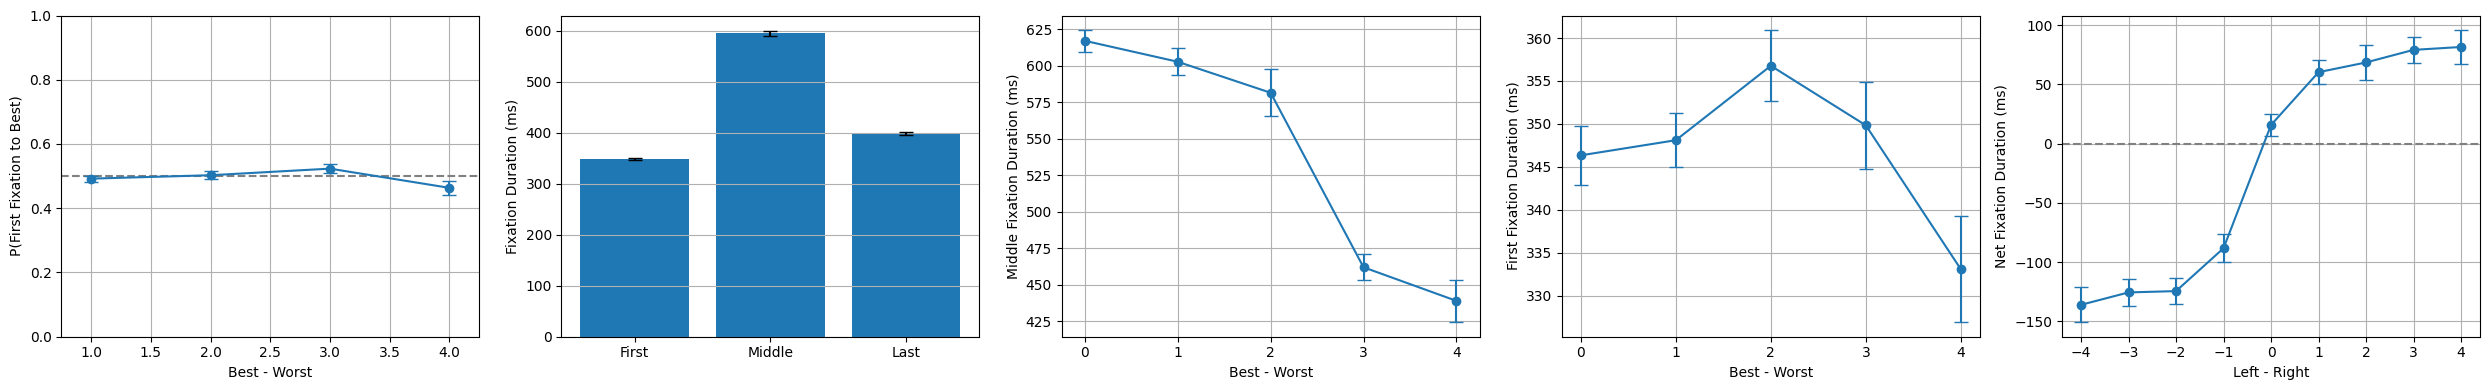

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_left_by_bin = first_fix_df.groupby('diff_bin')['choice'].apply(lambda x: (x == 0).mean())
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = first_fix_df.groupby('diff_bin')['signed_diff'].mean()
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_78644/906620643.py:109: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pan

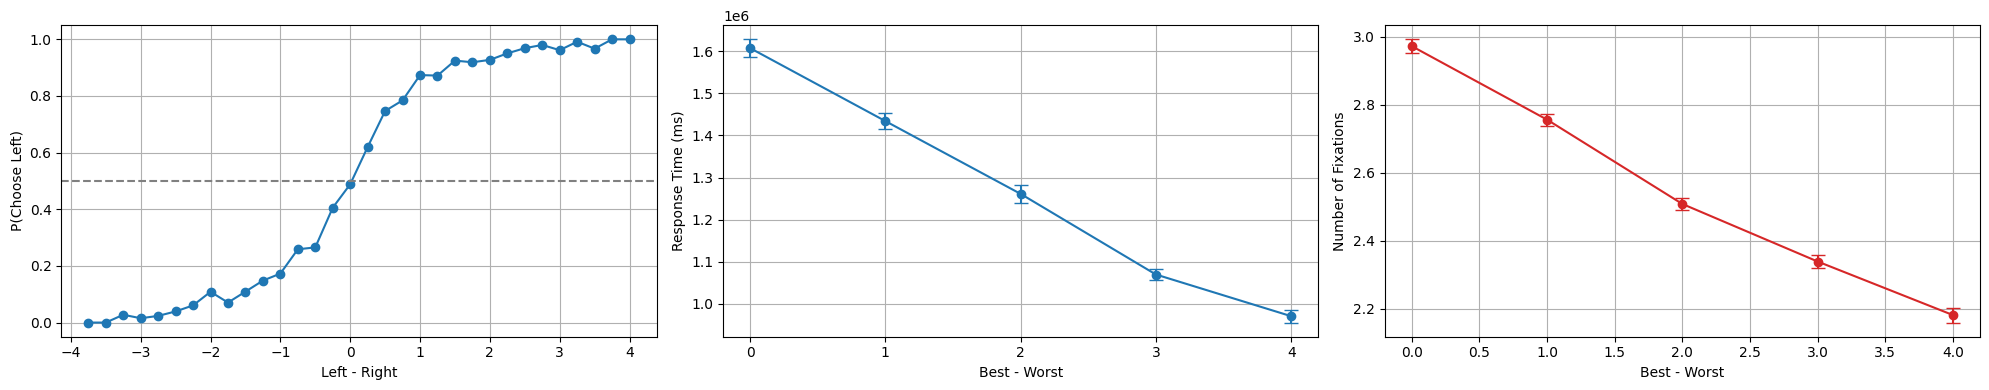

In [16]:
plot_fixation_properties(df_visible)
plot_basic_psychometrics(df_visible)